In [ ]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from einops import rearrange
from einops.layers.torch import Rearrange
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

class MAEDataset(Dataset):
    def __init__(self, root_dir, mode='pretrain', transform=None):
        self.root_dir = root_dir
        self.mode = mode
        self.transform = transform
        self.classes = ['no_sub', 'cdm', 'axion']
        self.samples = []

        if mode == 'pretrain':
            path = os.path.join(root_dir, 'no_sub')
            if os.path.exists(path):
                self.samples = [(os.path.join(path, f), 0) for f in os.listdir(path) if f.endswith('.npy')]
        else:
            for idx, cls in enumerate(self.classes):
                path = os.path.join(root_dir, cls)
                if os.path.exists(path):
                    self.samples.extend([(os.path.join(path, f), idx) for f in os.listdir(path) if f.endswith('.npy')])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        data = np.load(path, allow_pickle=True)
        
        # Phase 1: Recursive Unpacking
        # We manually tunnel down into the data until we find a numeric array
        curr = data
        while True:
            # If it's a 0-d object array 
            if isinstance(curr, np.ndarray) and curr.dtype == object and curr.ndim == 0:
                curr = curr.item()
            # If it's a list or tuple containing the array
            elif isinstance(curr, (list, tuple)) and len(curr) > 0:
                curr = curr[0]
            # If it's a multi-element object array
            elif isinstance(curr, np.ndarray) and curr.dtype == object and curr.ndim > 0:
                curr = curr[0]
            else:
                break
        
        # Phase 2: Standardization
        img = np.ascontiguousarray(curr, dtype=np.float32)
        
        # Ensure (1, H, W) for the Transformer
        if img.ndim == 2:
            img = np.expand_dims(img, axis=0)
        elif img.ndim == 3:
            if img.shape[0] != 1: 
                # If it's (H, W, 1), move channel to front. If (3, H, W), take first channel.
                if img.shape[2] == 1: img = img.transpose(2, 0, 1)
                else: img = img[0:1, :, :]
            
        img_tensor = torch.from_numpy(img)
        if self.transform:
            img_tensor = self.transform(img_tensor)
        return img_tensor, label

base_path = '/kaggle/input/datasets/bryanbradfo/gsoc-foundation-model/Dataset'
pretrain_ds = MAEDataset(base_path, mode='pretrain', transform=transforms.RandomRotation(180))
finetune_ds = MAEDataset(base_path, mode='finetune', transform=transforms.RandomRotation(180))

# Optimized for T4 x2
pre_loader = DataLoader(pretrain_ds, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
ft_loader = DataLoader(finetune_ds, batch_size=256, shuffle=True, num_workers=4, pin_memory=True)

In [30]:
def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)
    grid = np.stack(grid, axis=0)
    grid = grid.reshape([2, 1, grid_size, grid_size])
    
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = np.concatenate([np.zeros([1, embed_dim]), pos_embed], axis=0)
    return torch.from_numpy(pos_embed).float().unsqueeze(0)

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])
    return np.concatenate([emb_h, emb_w], axis=1)

def get_1d_sincos_pos_embed_from_grid(embed_dim, grid):
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega
    grid = grid.flatten()
    out = np.einsum('m,d->md', grid, omega)
    return np.concatenate([np.sin(out), np.cos(out)], axis=1)

class MAE(nn.Module):
    def __init__(self, img_size=64, patch_size=4, in_chans=1, embed_dim=128, depth=8, num_heads=8, decoder_embed_dim=64, decoder_depth=4, decoder_num_heads=4, mlp_ratio=4., masking_ratio=0.75):
        super().__init__()
        self.patch_size = patch_size
        self.masking_ratio = masking_ratio
        num_patches = (img_size // patch_size) ** 2
        
        self.patch_embed = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2=patch_size),
            nn.Linear(patch_size * patch_size * in_chans, embed_dim)
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim), requires_grad=False)
        
        self.encoder = nn.ModuleList([nn.TransformerEncoderLayer(embed_dim, num_heads, int(embed_dim*mlp_ratio), dropout=0, batch_first=True, norm_first=True) for _ in range(depth)])
        self.encoder_norm = nn.LayerNorm(embed_dim)
        
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim), requires_grad=False)
        self.decoder = nn.ModuleList([nn.TransformerEncoderLayer(decoder_embed_dim, decoder_num_heads, int(decoder_embed_dim*mlp_ratio), dropout=0, batch_first=True, norm_first=True) for _ in range(decoder_depth)])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size * patch_size * in_chans)
        
        self.initialize_weights(num_patches, embed_dim, decoder_embed_dim)

    def initialize_weights(self, num_patches, embed_dim, decoder_embed_dim):
        pos_embed = get_2d_sincos_pos_embed(embed_dim, int(num_patches**.5), cls_token=True)
        self.pos_embed.data.copy_(pos_embed)
        dec_pos_embed = get_2d_sincos_pos_embed(decoder_embed_dim, int(num_patches**.5), cls_token=True)
        self.decoder_pos_embed.data.copy_(dec_pos_embed)
        torch.nn.init.normal_(self.cls_token, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)

    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        return x_masked, mask, ids_restore

    def forward_encoder(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        x, mask, ids_restore = self.random_masking(x, self.masking_ratio)
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        x = torch.cat((cls_token.expand(x.shape[0], -1, -1), x), dim=1)
        for layer in self.encoder: x = layer(x)
        return self.encoder_norm(x), mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)
        x = x + self.decoder_pos_embed
        for layer in self.decoder: x = layer(x)
        x = self.decoder_norm(x)
        return self.decoder_pred(x)[:, 1:, :]

    def forward(self, x):
        latent, mask, ids_restore = self.forward_encoder(x)
        pred = self.forward_decoder(latent, ids_restore)
        target = rearrange(x, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=self.patch_size, p2=self.patch_size)
        loss = (pred - target) ** 2
        return loss.mean(), pred, mask

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MAE().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

for epoch in range(50):
    model.train()
    total_loss = 0
    for imgs, _ in pre_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss, _, _ = model(imgs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1} Pre-train Loss: {total_loss/len(pre_loader):.6f}")

torch.save(model.state_dict(), 'mae_pretrain.pth')

Epoch 1 Pre-train Loss: 0.100734
Epoch 2 Pre-train Loss: 0.056400
Epoch 3 Pre-train Loss: 0.021282
Epoch 4 Pre-train Loss: 0.009408
Epoch 5 Pre-train Loss: 0.007262
Epoch 6 Pre-train Loss: 0.006004
Epoch 7 Pre-train Loss: 0.005178
Epoch 8 Pre-train Loss: 0.004591
Epoch 9 Pre-train Loss: 0.004390
Epoch 10 Pre-train Loss: 0.003989
Epoch 11 Pre-train Loss: 0.003732
Epoch 12 Pre-train Loss: 0.003667
Epoch 13 Pre-train Loss: 0.003475
Epoch 14 Pre-train Loss: 0.003308
Epoch 15 Pre-train Loss: 0.003330
Epoch 16 Pre-train Loss: 0.003205
Epoch 17 Pre-train Loss: 0.003087
Epoch 18 Pre-train Loss: 0.003019
Epoch 19 Pre-train Loss: 0.002949
Epoch 20 Pre-train Loss: 0.002939
Epoch 21 Pre-train Loss: 0.002810
Epoch 22 Pre-train Loss: 0.002730
Epoch 23 Pre-train Loss: 0.002874
Epoch 24 Pre-train Loss: 0.002662
Epoch 25 Pre-train Loss: 0.002583
Epoch 26 Pre-train Loss: 0.002507
Epoch 27 Pre-train Loss: 0.002456
Epoch 28 Pre-train Loss: 0.002412
Epoch 29 Pre-train Loss: 0.002385
Epoch 30 Pre-train Loss

In [ ]:
class MAEClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes=3):
        super().__init__()
        self.encoder = encoder
        self.patch_embed = encoder.patch_embed
        self.cls_token = encoder.cls_token
        self.pos_embed = encoder.pos_embed
        self.blocks = encoder.encoder
        self.norm = encoder.encoder_norm
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        x = torch.cat((cls_token.expand(x.shape[0], -1, -1), x), dim=1)
        for block in self.blocks: x = block(x)
        return self.head(self.norm(x[:, 0]))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mae_model = MAE().to(device)

mae_model.load_state_dict(torch.load('mae_pretrain.pth', weights_only=True))

classifier = MAEClassifier(mae_model, embed_dim=128).to(device)
if torch.cuda.device_count() > 1:
    classifier = nn.DataParallel(classifier)

optimizer_ft = optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    classifier.train()
    total_loss = 0
    for imgs, labels in ft_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        loss = criterion(classifier(imgs), labels)
        loss.backward()
        optimizer_ft.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Fine-tune Loss: {total_loss/len(ft_loader):.6f}")

torch.save(classifier.state_dict(), 'mae_classifier_final.pth')

Epoch 1 Fine-tune Loss: 0.479632
Epoch 2 Fine-tune Loss: 0.252385
Epoch 3 Fine-tune Loss: 0.232287
Epoch 4 Fine-tune Loss: 0.193707
Epoch 5 Fine-tune Loss: 0.195566
Epoch 6 Fine-tune Loss: 0.233551
Epoch 7 Fine-tune Loss: 0.162010
Epoch 8 Fine-tune Loss: 0.184639
Epoch 9 Fine-tune Loss: 0.172724
Epoch 10 Fine-tune Loss: 0.148720
Epoch 11 Fine-tune Loss: 0.175291
Epoch 12 Fine-tune Loss: 0.174470
Epoch 13 Fine-tune Loss: 0.166590
Epoch 14 Fine-tune Loss: 0.148752
Epoch 15 Fine-tune Loss: 0.140902
Epoch 16 Fine-tune Loss: 0.132129
Epoch 17 Fine-tune Loss: 0.119177
Epoch 18 Fine-tune Loss: 0.152459
Epoch 19 Fine-tune Loss: 0.129760
Epoch 20 Fine-tune Loss: 0.144071


Final Multi-class AUC: 0.9966


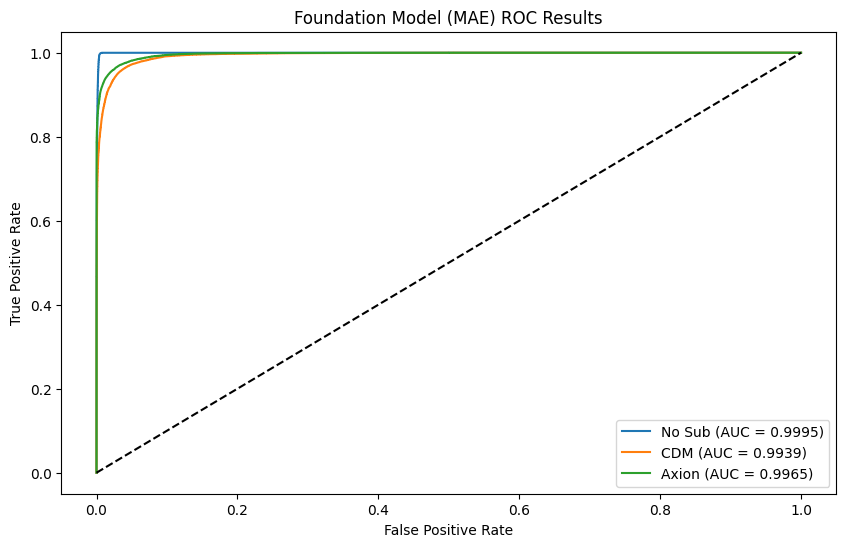

In [33]:
classifier.eval()
y_true, y_probs = [], []
with torch.no_grad():
    for imgs, labels in ft_loader:
        outputs = classifier(imgs.to(device))
        probs = torch.softmax(outputs, dim=1)
        y_probs.extend(probs.cpu().numpy())
        y_true.extend(labels.numpy())

y_probs, y_true = np.array(y_probs), np.array(y_true)
print(f"Final Multi-class AUC: {roc_auc_score(y_true, y_probs, multi_class='ovr'):.4f}")

plt.figure(figsize=(10, 6))
classes = ['No Sub', 'CDM', 'Axion']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true == i, y_probs[:, i])
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc_score(y_true == i, y_probs[:, i]):.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Foundation Model (MAE) ROC Results')
plt.legend(); plt.show()